In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from ase.visualize import view
from ase.cluster import FaceCenteredCubic
import abtem
import ase
import matplotlib.pyplot as plt

import numpy as np
import abtem
from ase.build import bulk
from ase import Atoms


[mallard:1138287] mca_base_component_repository_open: unable to open mca_btl_openib: librdmacm.so.1: cannot open shared object file: No such file or directory (ignored)


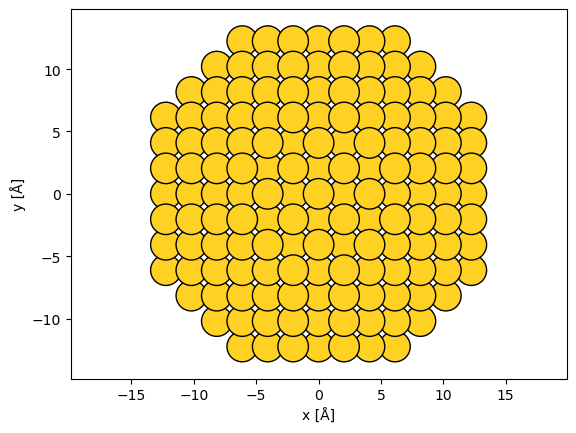

In [3]:
surfaces = [(1, 0, 0), (1, 1, 0), (1, 1, 1)]
layers = [6, 9, 5]
lc = 4.08

nanoparticle = FaceCenteredCubic("Au", surfaces, layers, latticeconstant=lc)

abtem.show_atoms(nanoparticle, scale=0.9);


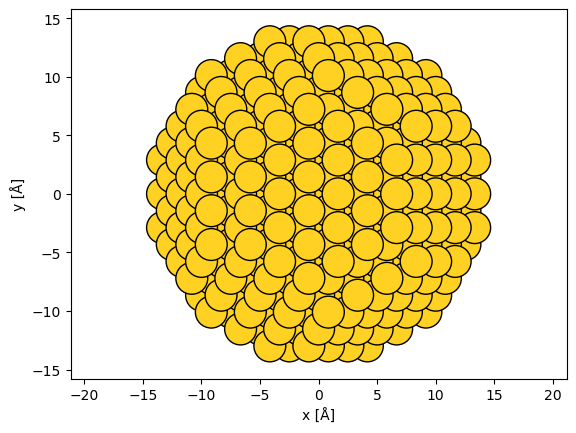

In [4]:
rotated_nanoparticle = nanoparticle.copy()

rotated_nanoparticle.rotate(45, "x")

y_angle = np.degrees(np.arctan(1 / np.sqrt(2)))

rotated_nanoparticle.rotate(y_angle, "y")

abtem.show_atoms(rotated_nanoparticle, scale=1);

In [5]:
centered_nanoparticle = rotated_nanoparticle.copy()

centered_nanoparticle.center(vacuum=2)

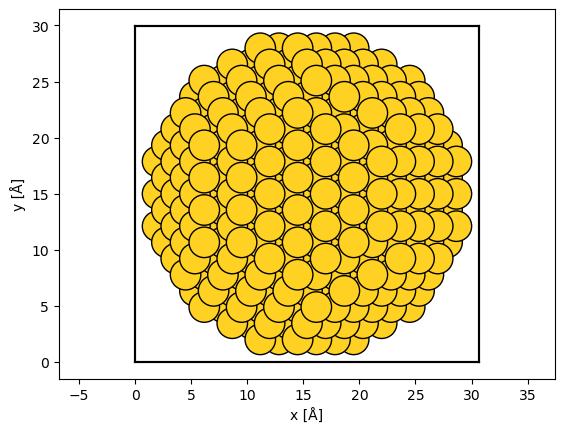

In [6]:
abtem.show_atoms(centered_nanoparticle, scale=1);

In [7]:
substrate = ase.build.bulk("C", cubic=True)

# repeat diamond structure
substrate = substrate * (100, 100, 5)

# displace atoms with a standard deviation of 50 % of the bond length
bl = 1.54  # Bond length
rng = np.random.default_rng(seed=10)
substrate.positions[:] += rng.normal(size=(len(substrate), 3)) * 0.5 * bl

# wrap the atoms displaced outside the cell back into the cell
substrate.wrap()

In [8]:
cut_nanoparticle = centered_nanoparticle.copy()

mask = cut_nanoparticle.positions[:, 2] < 5

# deletion *requires* providing the indices, i.e. boolean indexing does not work
del cut_nanoparticle[np.where(mask)[0]]

# center nanoparticle relative to substrate
cut_nanoparticle.set_cell(substrate.cell)
cut_nanoparticle.center()

# shift nanoparticle in the z-direction
cut_nanoparticle.positions[:, 2] += 15

In [9]:
supported_nanoparticle = substrate + cut_nanoparticle

supported_nanoparticle.center(axis=2, vacuum=5)

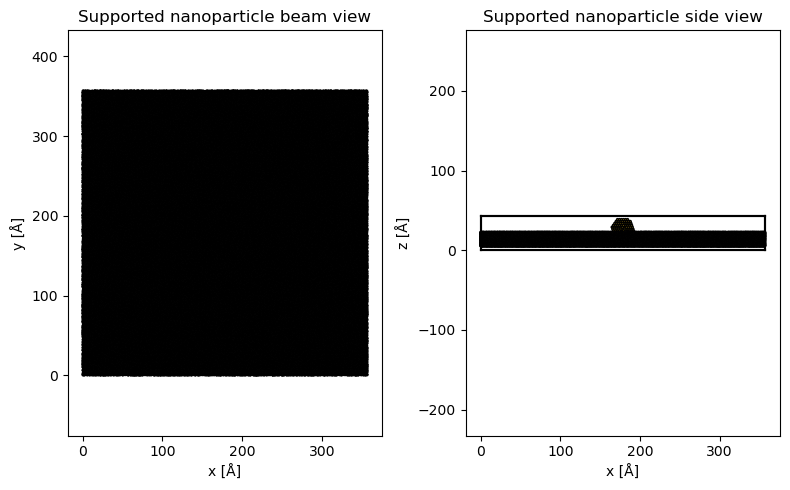

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5))
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

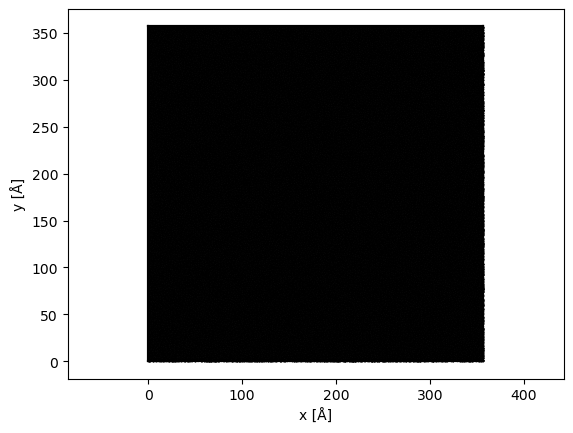

In [11]:

# === Base nanoparticle parameters ===
surfaces = [(1, 0, 0), (1, 1, 0), (1, 1, 1)]
layers = [6, 9, 5]
lc = 4.08

# === Base nanoparticle ===
base_np = FaceCenteredCubic("Au", surfaces, layers, latticeconstant=lc)

# === Prepare substrate ===
substrate = bulk("C", cubic=True) * (100, 100, 5)
bl = 1.54
rng = np.random.default_rng(seed=10)
substrate.positions[:] += rng.normal(size=(len(substrate), 3)) * 0.5 * bl
substrate.wrap()

# === Generate multiple nanoparticles ===
n_particles = 10  # number of nanoparticles
nanoparticles = []

for i in range(n_particles):
    np_copy = base_np.copy()
    
    # --- Random size variation ---
    scale_factor = rng.uniform(0.6, 1.4)
    np_copy.set_cell(np_copy.cell * scale_factor, scale_atoms=True)
    
    # --- Random orientation ---
    rot_x = rng.uniform(0, 360)
    rot_y = rng.uniform(0, 360)
    rot_z = rng.uniform(0, 360)
    np_copy.rotate(rot_x, "x")
    np_copy.rotate(rot_y, "y")
    np_copy.rotate(rot_z, "z")
    
    # --- Center in substrate box and add random xy position ---
    np_copy.set_cell(substrate.cell)
    np_copy.center()
    
    # Random xy shift within substrate area (avoid edges)
    shift_x = rng.uniform(-150, 150)
    shift_y = rng.uniform(-150, 150)
    
    # --- Random z placement (depth/height) ---
    # some slightly embedded, others floating above
    shift_z = rng.uniform(10, 25)
    
    np_copy.positions[:, 0] += shift_x
    np_copy.positions[:, 1] += shift_y
    np_copy.positions[:, 2] += shift_z
    
    nanoparticles.append(np_copy)

# === Combine everything ===
supported_nanoparticles = substrate.copy()
for np_atom in nanoparticles:
    supported_nanoparticles += np_atom

# Optional: add vacuum above the system
supported_nanoparticles.center(axis=2, vacuum=5)

# === Visualize ===
abtem.show_atoms(supported_nanoparticles, scale=0.7)


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>)

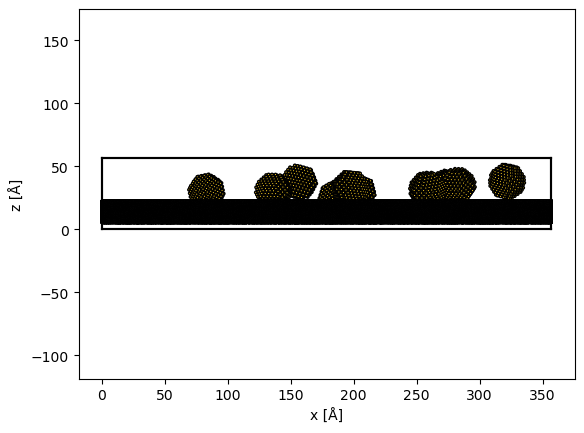

In [12]:
abtem.show_atoms(supported_nanoparticles, plane = 'xz')

In [13]:
potential = abtem.Potential(
    supported_nanoparticles,
    sampling = 1,
    projection = 'infinite'
)

[########################################] | 100% Completed | 924.06 ms


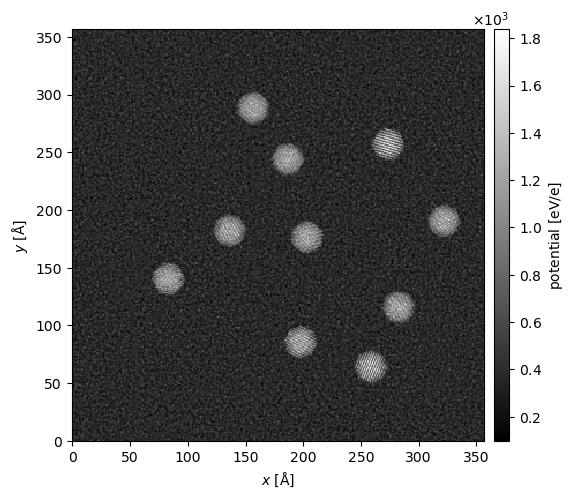

In [14]:
potential.show(cbar = True, cmap = 'gray')

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>)

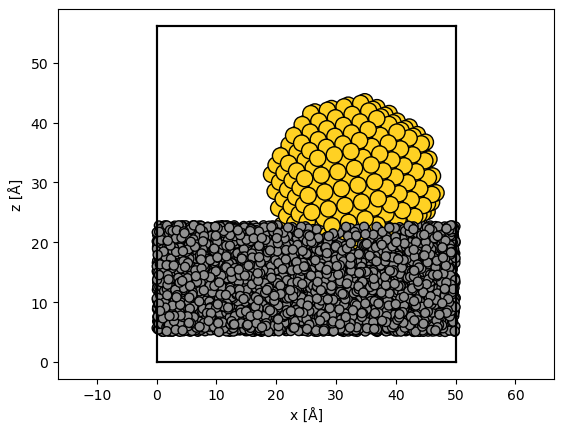

In [ ]:
# Assume your full structure is 'supported_nanoparticles'

# Define crop center and size
center_x, center_y = 75, 150
crop_size = 50

# Compute boundaries
x_min, x_max = center_x - crop_size / 2, center_x + crop_size / 2
y_min, y_max = center_y - crop_size / 2, center_y + crop_size / 2

# Create a mask for atoms within the crop area
positions = supported_nanoparticles.positions
mask = (
    (positions[:, 0] >= x_min) &
    (positions[:, 0] <= x_max) &
    (positions[:, 1] >= y_min) &
    (positions[:, 1] <= y_max)
)

# Extract the region of interest
cropped = supported_nanoparticles[mask]

# Optionally, redefine cell to the cropped region for clarity
cell = supported_nanoparticles.cell.copy()
cell[0, 0] = crop_size
cell[1, 1] = crop_size
cropped.set_cell(cell)
cropped.center(axis=(0, 1))  # recenters within new cell, keeps z unchanged

# Show the cropped area
abtem.show_atoms(cropped, scale=1, plane = 'xz')

[                                        ] | 0% Completed | 226.37 us

[########################################] | 100% Completed | 101.52 ms


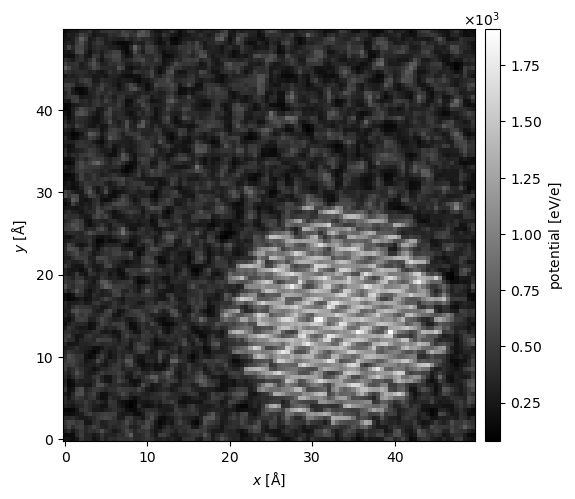

In [18]:
potential_cropped = abtem.Potential(
    cropped,
    sampling = .5,
    projection = 'infinite'
)
potential_cropped.show(cbar = True, cmap = 'gray')